# Lecture 5 - Jan 29,  2026 #

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests


In [2]:
tips = sns.load_dataset("tips")
print(tips.head)

<bound method NDFrame.head of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>


<Axes: xlabel='total_bill', ylabel='tip'>

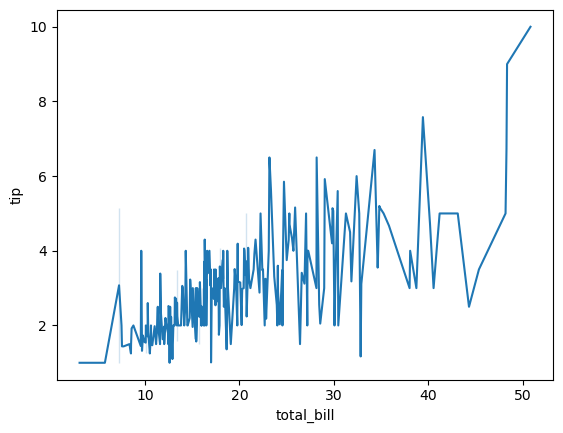

In [3]:
sns.lineplot(
    data=tips,        # choose our dataset
    x='total_bill',   # define our x variable
    y='tip'           # define our y variable
)


<Axes: xlabel='total_bill', ylabel='tip'>

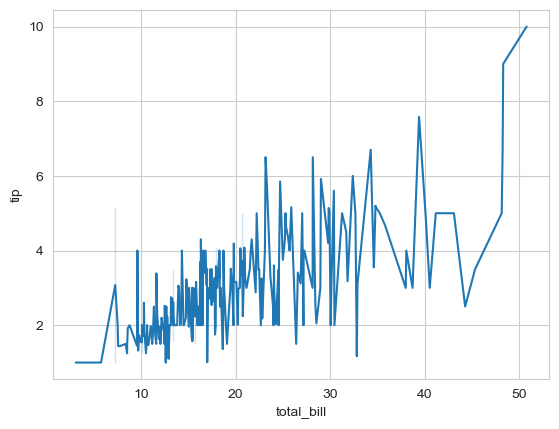

In [5]:
sns.set_style("whitegrid")
sns.lineplot(
    data=tips,        # choose our dataset
    x='total_bill',   # define our x variable
    y='tip'           # define our y variable
)

<Axes: xlabel='total_bill', ylabel='tip'>

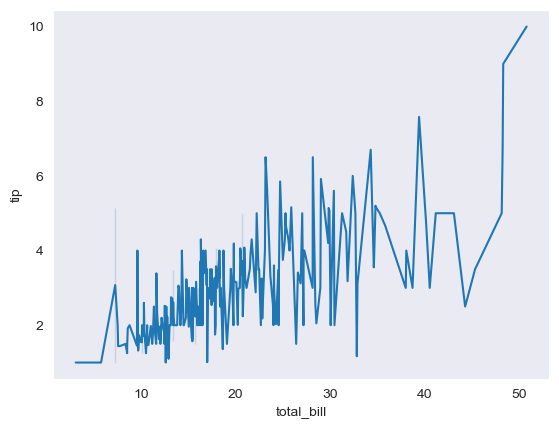

In [6]:
sns.set_style("dark")
sns.lineplot(
    data=tips,        # choose our dataset
    x='total_bill',   # define our x variable
    y='tip'           # define our y variable
)

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

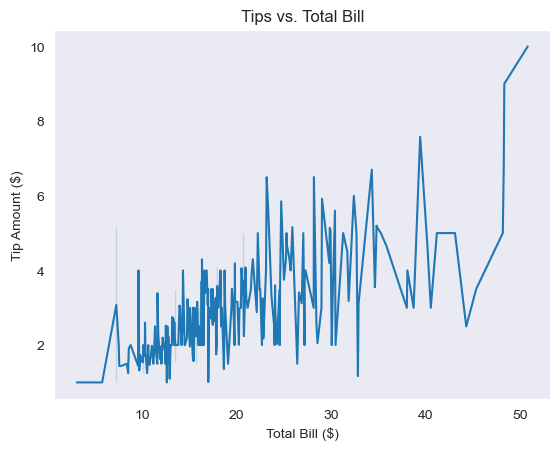

In [7]:
tipgraph = sns.lineplot(
    data=tips,
    x='total_bill',
    y='tip'
)

tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)


<Axes: xlabel='total_bill', ylabel='tip'>

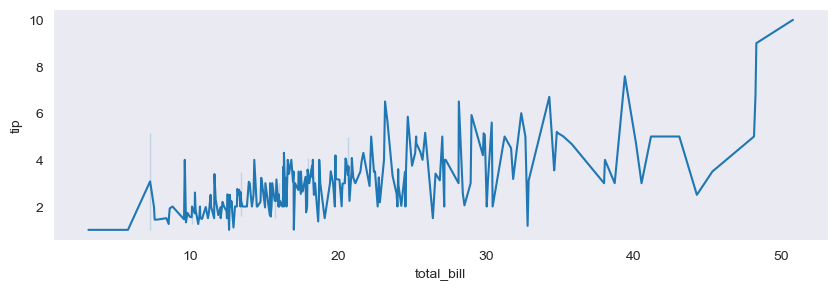

In [9]:
fig = plt.subplots(figsize=(10, 3))
sns.lineplot(
    data=tips,        # choose our dataset
    x='total_bill',   # define our x variable
    y='tip'           # define our y variable
)

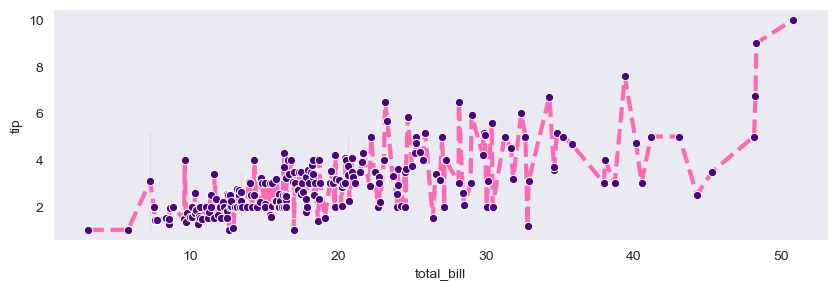

In [ ]:
fig = plt.subplots(figsize=(10, 3))
tipgraph = sns.lineplot(
    data=tips,
    x='total_bill',
    y='tip',
    color='hotpink',
    linestyle='--',
    linewidth=3,
    marker='o',
    markerfacecolor='indigo'
)


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

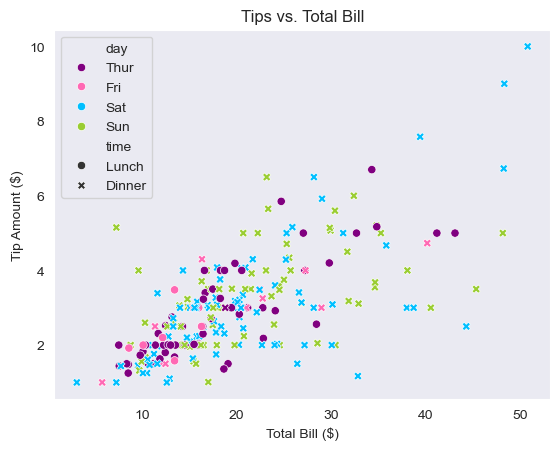

In [14]:
tipgraph = sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    style='time',
    hue='day',
    palette=['purple', 'hotpink', 'deepskyblue', 'yellowgreen']
)

tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)


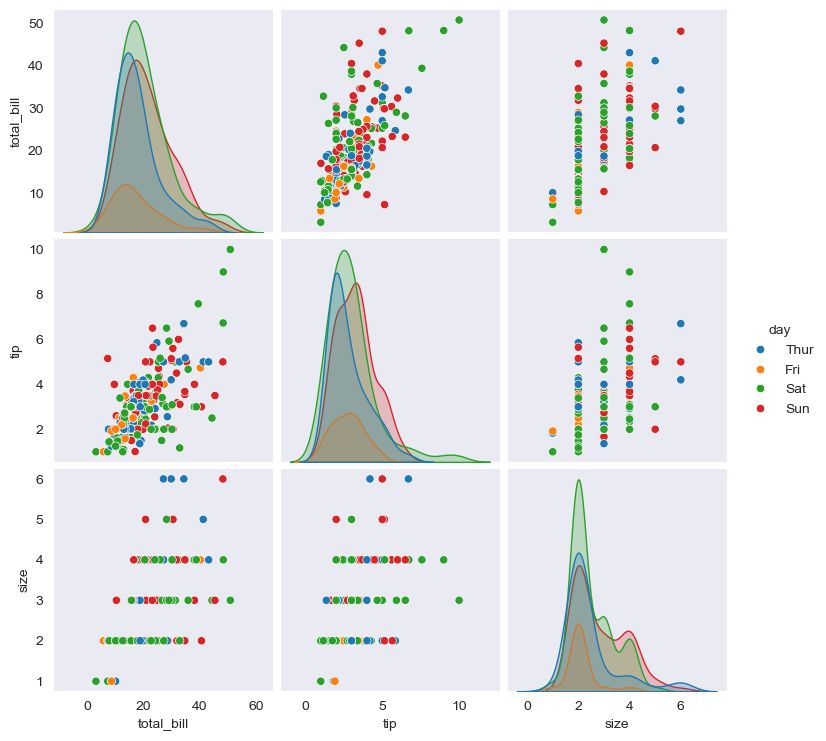

In [15]:
sns.pairplot(data=tips, hue='day')

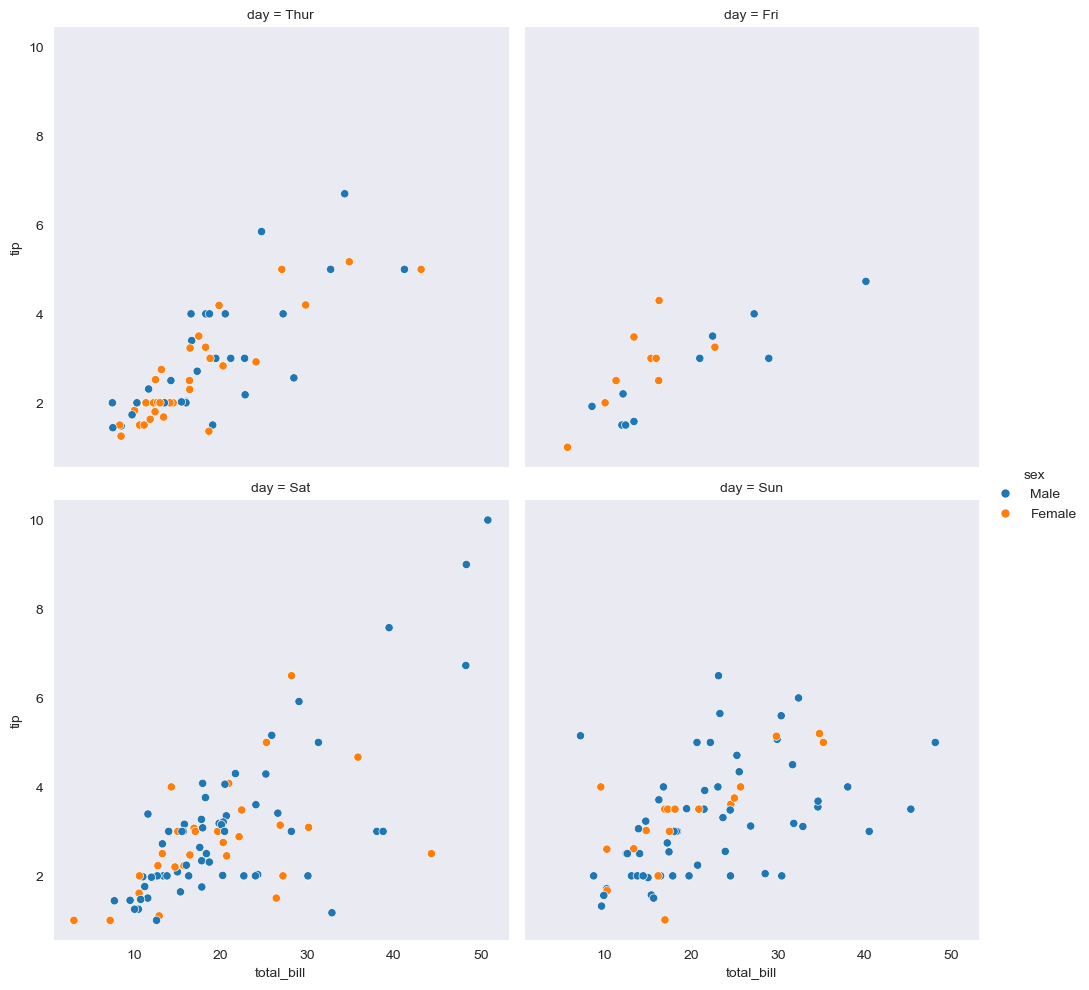

In [16]:
daysplot = sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    col="day",
    kind="scatter",
    col_wrap=2
)


In [19]:
import plotly.graph_objects as go  # 'go' is 'graph objects'

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))

In [20]:
graph.update_layout(
    title='Pirate Scores',
    xaxis_title='Pirates',
    yaxis_title='Score'
)
graph.show()

In [22]:
graph = go.Figure()

graph.add_trace(
    go.Scatter(
        x=x1,
        y=y1,
        mode='markers',          # points only (scatter plot)
        marker=dict(
            size=15,             # point size
            color='hotpink',     # point colour
            opacity=1,           # transparency
            line=dict(
                width=5,
                color='purple'   # point outline
            )
        )
    )
)

graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Scores',
    width=500,
    height=500
)


In [24]:
!pip install wordcloud
from wordcloud import WordCloud
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
    on_bad_lines='skip'
)

df


,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


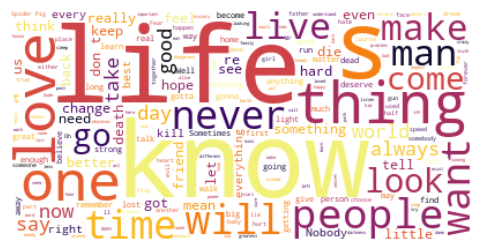

In [25]:
# Join all quotes into one string
text = " ".join(each for each in df["quote"])

# Generate word cloud
wordcloud = WordCloud(
    background_color="white",
    colormap="inferno"
).generate(text)

# Plot the word cloud
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
plt.show()

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45437 sha256=a730b02be8fc4cea1ac2eedf57ea4c4ee56aea703e385573f985eb8f8f893425
  Stored in directory: c:\users\charlotte\appdata\local\pip\cache\wheels\86\29\d8\0f3c5a37c967a34fb40aaabd414f92104d2ad5fb149c0114a1
Successfully built matplotlib-venn


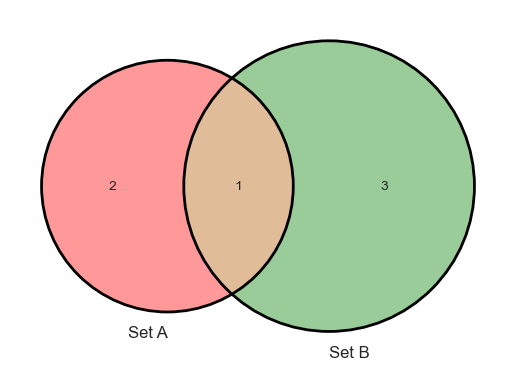

In [28]:
!pip install matplotlib-venn
from matplotlib_venn import venn2, venn2_circles

# Define sets
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# Plot Venn diagram
fig, ax = plt.subplots()
venn2([A, B], set_labels=("Set A", "Set B"))
venn2_circles([A, B])

plt.show()

c:\Users\Charlotte\miniconda3\envs\dsi_participant\lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



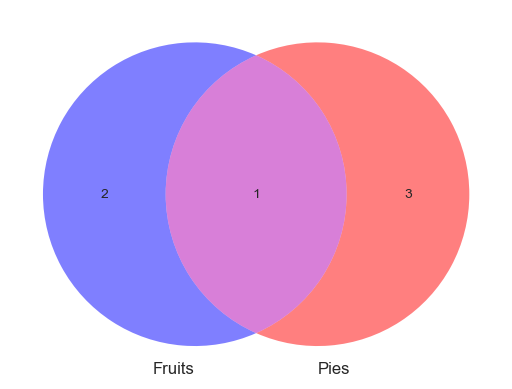

In [29]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2_unweighted

# Define sets
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# Create unweighted Venn diagram
diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),
    set_colors=('blue', 'red'),
    alpha=0.5
)

plt.show()


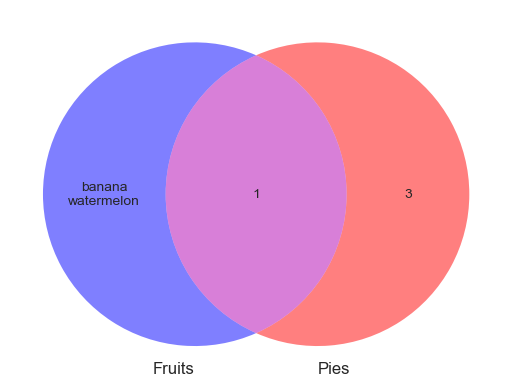

In [33]:
diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),
    set_colors=('blue', 'red'),
    alpha=0.5
)
# Left-only (A − B)
diagram.get_label_by_id("10").set_text("\n".join(A - B))
plt.show()


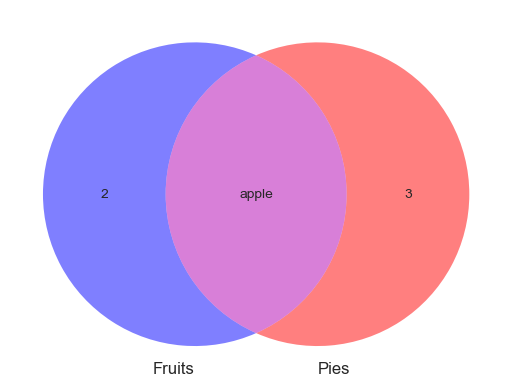

In [34]:
diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),
    set_colors=('blue', 'red'),
    alpha=0.5
)
# Intersection (A ∩ B)
diagram.get_label_by_id("11").set_text("\n".join(A & B))



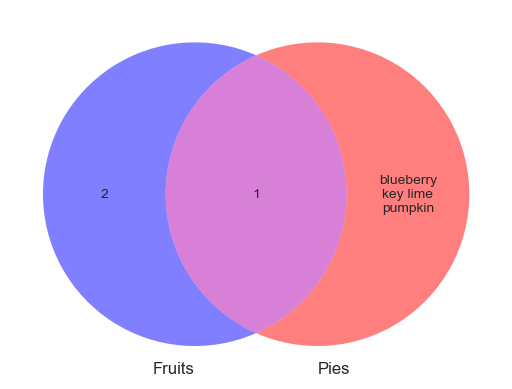

In [35]:
diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),
    set_colors=('blue', 'red'),
    alpha=0.5
)
# Right-only (B − A)
diagram.get_label_by_id("01").set_text("\n".join(B - A))

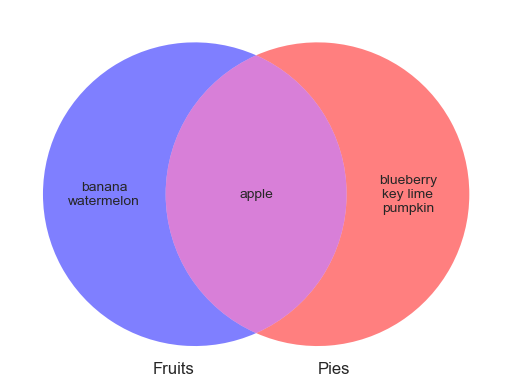

In [36]:
diagram = venn2_unweighted(
    [A, B],
    set_labels=('Fruits', 'Pies'),
    set_colors=('blue', 'red'),
    alpha=0.5
)
# Left-only (A − B)
diagram.get_label_by_id("10").set_text("\n".join(A - B))

# Intersection (A ∩ B)
diagram.get_label_by_id("11").set_text("\n".join(A & B))

# Right-only (B − A)
diagram.get_label_by_id("01").set_text("\n".join(B - A))
plt.show()